# 03. Evaluation: how to score a fraud model

Before building any model, build the scorekeeper. This notebook implements every metric the
project uses **by hand**, on a ten-provider example small enough to check on paper, then
verifies each one against scikit-learn. At the end the same functions are run on the real
data, using the rule-based flags from notebook 02 as a stand-in model.

The functions built here are saved in `src/metrics.py` so later notebooks import them
instead of re-implementing them. Every model in the project gets scored the same way.

## Why the metric choice is the whole problem

A fraud model does not output "fraud" or "not fraud." It outputs a **score** per provider,
higher meaning more suspicious. To turn scores into decisions you pick a cutoff, the
**threshold**, and flag everyone at or above it. Move the threshold and the decisions change.
One model, infinitely many behaviors.

Two facts about this data make the usual metrics useless:

- **68 positives among 1.3M providers.** A model that flags nobody is 99.995% accurate.
  Accuracy measures nothing here.
- **Investigators can work a fixed number of leads.** The question is never "is this provider
  fraudulent, yes or no?" It is "which few hundred should we look at first?" That is a
  ranking question, and it needs ranking metrics.

The metrics, in the order they are built:

| metric | question it answers | used for |
|---|---|---|
| confusion counts at a threshold | at this cutoff, how many right and wrong of each kind? | understanding the tradeoff |
| ROC curve | as the cutoff moves, how do the catch rate and false-alarm rate trade off? | comparing models |
| ROC AUC | across all cutoffs, how well does the model rank positives above negatives? | model selection |
| precision at k | if investigators take the top k, what fraction are real? | deployment |
| PR curve and average precision | like ROC, but honest about the 1-in-20,000 base rate | model selection under imbalance |

Every acronym: TP true positive, FP false positive, FN false negative, TN true negative,
TPR true positive rate, FPR false positive rate, ROC receiver operating characteristic (a
WWII radar term that tells you nothing useful; ignore the name), AUC area under the curve,
PR precision-recall.

## 0. Setup

**What this cell does:** imports, opens the database read-only, and sets up plotting.

**Why read-only:** this notebook never writes a table. Opening read-only means it cannot
collide with another notebook that is writing.

In [1]:
import sys
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn import metrics as skm

DB_PATH = "C:/Users/palla/OneDrive/Documents/Coding Projects/Medicare Fraud ML/database/medicare_fraud.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)
con.execute("SET enable_progress_bar = false")

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

# Colors for the charts. Blue for the model, gray for the "random" reference line.
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a94"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. A ten-provider example

Ten providers. Four are truly fraudulent (label 1), six are clean (label 0). A model has
scored them, and they are listed from highest score to lowest. Small enough that every number
below can be checked by hand.

**What this cell does:** builds the example as two arrays, `scores` and `y`, and shows them.

In [2]:
toy = pd.DataFrame({
    "score": [0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.55, 0.40, 0.30, 0.10],
    "label": [1,    1,    0,    1,    0,    0,    1,    0,    0,    0],
})
scores, y = toy["score"].to_numpy(), toy["label"].to_numpy()
toy.T

,0,1,2,3,4,5,6,7,8,9
score,0.95,0.9,0.85,0.8,0.7,0.6,0.55,0.4,0.3,0.1
label,1.00,1.0,0.00,1.0,0.0,0.0,1.00,0.0,0.0,0.0


## 2. One threshold: the confusion counts

Pick a cutoff, say 0.60, and flag everyone at or above it. Each provider then lands in one of
four boxes:

| | actually fraud | actually clean |
|---|---|---|
| **flagged** | TP, true positive | FP, false positive |
| **not flagged** | FN, false negative | TN, true negative |

Two rates come out of those four counts:

- **TPR (true positive rate, also called recall)** = TP / (TP + FN). Of all the real fraud,
  what fraction did we flag? The denominator is the number of positives, fixed by reality.
- **FPR (false positive rate)** = FP / (FP + TN). Of all the clean providers, what fraction did
  we flag anyway? The denominator is the number of negatives, also fixed.

One thing that trips people up: TP + FN is always the total number of positives. Catching
more fraud (higher TP) and missing less fraud (lower FN) are the same act, not two. The real
tension is TP against FP: catching more fraud means flagging more innocent providers.

**What this cell does:** writes `confusion_at()` and runs it at threshold 0.60. At that cutoff
six providers are flagged (scores 0.95 through 0.60), three of them fraud and three clean.

In [3]:
def confusion_at(scores, y, threshold):
    """Counts of TP, FP, FN, TN when everything at or above `threshold` is flagged."""
    flagged = scores >= threshold
    return {
        "TP": int(np.sum(flagged & (y == 1))),
        "FP": int(np.sum(flagged & (y == 0))),
        "FN": int(np.sum(~flagged & (y == 1))),
        "TN": int(np.sum(~flagged & (y == 0))),
    }

c = confusion_at(scores, y, 0.60)
print(c)
print("TPR (recall) =", c["TP"] / (c["TP"] + c["FN"]))
print("FPR          =", c["FP"] / (c["FP"] + c["TN"]))

{'TP': 3, 'FP': 3, 'FN': 1, 'TN': 3}
TPR (recall) = 0.75
FPR          = 0.5


## 3. Every threshold: the ROC curve

Now slide the threshold from "flag nobody" down to "flag everybody," and at each step record
the pair (FPR, TPR). Plot FPR on the x-axis and TPR on the y-axis. That plot is the ROC curve.
That is all it is: one dot per threshold, connected.

Notice the shape. Each time the threshold drops past a fraudulent provider, TPR goes up and
FPR stays put, so the line moves straight up. Each time it drops past a clean provider, the
line moves straight right. A real ROC curve is a staircase of those two moves.

**What this cell does:** writes `roc_points()`, which sorts by score and walks the threshold
down, and prints the table of (threshold, TP, FP, TPR, FPR) at every step. Compare it to the
worked example in the markdown at the top of the project conversation: it should match line
for line.

In [4]:
def roc_points(scores, y):
    """Walk the threshold from strictest to loosest; return fpr, tpr, thresholds."""
    n_pos, n_neg = int(np.sum(y == 1)), int(np.sum(y == 0))
    order = np.argsort(-scores, kind="stable")          # highest score first
    s_sorted, y_sorted = scores[order], y[order]
    tp_cum = np.cumsum(y_sorted == 1)                   # positives flagged so far
    fp_cum = np.cumsum(y_sorted == 0)                   # negatives flagged so far
    # if several providers share a score, the threshold lands after the last of them
    distinct = np.r_[s_sorted[1:] != s_sorted[:-1], True]
    tpr = np.r_[0.0, tp_cum[distinct] / n_pos]
    fpr = np.r_[0.0, fp_cum[distinct] / n_neg]
    thresholds = np.r_[np.inf, s_sorted[distinct]]
    return fpr, tpr, thresholds

fpr, tpr, thr = roc_points(scores, y)
pd.DataFrame({"threshold": thr, "TP": (tpr * 4).astype(int), "FP": (fpr * 6).astype(int),
              "TPR": tpr.round(2), "FPR": fpr.round(2)})

,threshold,TP,FP,TPR,FPR
0,inf,0,0,0.00,0.00
1,0.95,1,0,0.25,0.00
2,0.90,2,0,0.50,0.00
3,0.85,2,1,0.50,0.17
4,0.80,3,1,0.75,0.17
5,0.70,3,2,0.75,0.33
6,0.60,3,3,0.75,0.50
7,0.55,4,3,1.00,0.50
8,0.40,4,4,1.00,0.67
9,0.30,4,5,1.00,0.83


## 4. AUC, two ways that must agree

**Way one: the area under the staircase.** The plot is a 1 x 1 box, so the area is between
0 and 1. A perfect model goes straight up the left edge then across the top: area 1.0. A
random model wanders along the diagonal: area 0.5. Below 0.5 means the model ranks backwards,
usually a sign flip in the code rather than a bad model.

**Way two: count pairs.** Take every (fraud, clean) pair. With 4 fraud and 6 clean there are
24 pairs. In how many does the fraud provider score higher? That fraction **is** the AUC.
Not an analogy, an exact identity: AUC is the probability that a randomly chosen positive
outranks a randomly chosen negative. This is the definition to memorize, because it makes the
three consequences obvious:

1. **It is threshold-free.** No cutoff was chosen. AUC judges the ranking, not any decision.
2. **It only sees order.** Multiply every score by 0.01 and AUC is unchanged. A model with a
   great AUC can output probabilities that are wildly wrong in absolute terms.
3. **It ignores the base rate.** Every pair is one positive against one negative, so the
   200-to-1 imbalance never enters. Good for comparing across months; misleading if you read
   it as "what investigators will see."

**What the next cell does:** computes the area by the trapezoid rule on the staircase, then
computes it again by counting pairs, then asks scikit-learn. All three must agree. With no
tied scores they agree exactly; the pair-counting function gives ties half credit, which is
also what scikit-learn does.

In [5]:
def auc_trapezoid(fpr, tpr):
    """Area under the curve by the trapezoid rule."""
    return float(np.sum((fpr[1:] - fpr[:-1]) * (tpr[1:] + tpr[:-1]) / 2.0))

def auc_pairs(scores, y):
    """AUC as the fraction of (positive, negative) pairs where the positive scores higher.
    Ties count as half. Written the slow, obvious way so it is easy to read."""
    pos, neg = scores[y == 1], scores[y == 0]
    wins = 0.0
    for p in pos:
        for n in neg:
            wins += 1.0 if p > n else (0.5 if p == n else 0.0)
    return wins / (len(pos) * len(neg))

print("trapezoid :", round(auc_trapezoid(fpr, tpr), 4))
print("pairs     :", round(auc_pairs(scores, y), 4), " (20 of 24 pairs won)")
print("sklearn   :", round(skm.roc_auc_score(y, scores), 4))

trapezoid : 0.8333
pairs     : 0.8333  (20 of 24 pairs won)
sklearn   : 0.8333


## 5. Precision at k: the deployment metric

Nobody deploys a threshold. They deploy a **capacity**: investigators can work k leads this
month. Sort by score, take the top k, done. The threshold is whatever score lands at rank k
and it drifts month to month.

So the metric that matches deployment is **precision at k**: of the k providers at the top
of the ranking, what fraction are actually positives? Its partner, **recall at k**, asks what
fraction of all positives made it into the top k.

On the toy example with k = 3, the top three are scores 0.95, 0.90, 0.85. Two of those are
fraud, so precision at 3 is 2/3, and recall at 3 is 2/4 since two of the four fraud providers
were caught.

**What this cell does:** writes both functions and runs them for k from 1 to 10.

In [6]:
def precision_at_k(scores, y, k):
    """Of the k highest-scoring rows, what fraction are positives?"""
    top = np.argsort(-scores, kind="stable")[:k]
    return float(np.mean(y[top]))

def recall_at_k(scores, y, k):
    """Of all positives, what fraction land in the top k?"""
    top = np.argsort(-scores, kind="stable")[:k]
    return float(np.sum(y[top]) / np.sum(y == 1))

pd.DataFrame({
    "k": range(1, 11),
    "precision@k": [round(precision_at_k(scores, y, k), 2) for k in range(1, 11)],
    "recall@k":    [round(recall_at_k(scores, y, k), 2)    for k in range(1, 11)],
})

,k,precision@k,recall@k
0,1,1.00,0.25
1,2,1.00,0.50
2,3,0.67,0.50
3,4,0.75,0.75
4,5,0.60,0.75
5,6,0.50,0.75
6,7,0.57,1.00
7,8,0.50,1.00
8,9,0.44,1.00
9,10,0.40,1.00


## 6. The precision-recall curve and average precision

The ROC curve is blind to the base rate. On the real data, an FPR of 0.008 looks like nothing
on the x-axis, but it is 10,000 innocent providers in the investigation queue. ROC cannot show
that because it never divides by the number of things flagged.

The **precision-recall (PR) curve** fixes this. Walk the threshold exactly as before, but at
each step plot recall on the x-axis and precision on the y-axis. Precision divides by the
number flagged, so the base rate is baked in. A random model's PR curve sits flat at the
positive rate, which on the real data is 0.00005. A ROC curve cannot tell you that.

**Average precision (AP)** is the area under the PR curve. It is computed as the sum over
thresholds of (gain in recall) x (precision at that step), which is what scikit-learn does.
Random is roughly the positive rate; perfect is 1.0.

**What this cell does:** writes `pr_points()` and `average_precision()`, prints the PR table,
and checks AP against scikit-learn.

In [7]:
def pr_points(scores, y):
    """Precision and recall at every distinct threshold, strictest first."""
    n_pos = int(np.sum(y == 1))
    order = np.argsort(-scores, kind="stable")
    s_sorted, y_sorted = scores[order], y[order]
    tp_cum = np.cumsum(y_sorted == 1)
    n_flagged = np.arange(1, len(scores) + 1)
    distinct = np.r_[s_sorted[1:] != s_sorted[:-1], True]
    return tp_cum[distinct] / n_flagged[distinct], tp_cum[distinct] / n_pos, s_sorted[distinct]

def average_precision(scores, y):
    """Area under the PR curve as sum of (recall gained) x (precision at that step)."""
    precision, recall, _ = pr_points(scores, y)
    recall_prev = np.r_[0.0, recall[:-1]]
    return float(np.sum((recall - recall_prev) * precision))

prec, rec, pthr = pr_points(scores, y)
print(pd.DataFrame({"threshold": pthr, "precision": prec.round(2), "recall": rec.round(2)}).to_string(index=False))
print()
print("average precision, by hand:", round(average_precision(scores, y), 4))
print("average precision, sklearn:", round(skm.average_precision_score(y, scores), 4))

 threshold  precision  recall
      0.95       1.00    0.25
      0.90       1.00    0.50
      0.85       0.67    0.50
      0.80       0.75    0.75
      0.70       0.60    0.75
      0.60       0.50    0.75
      0.55       0.57    1.00
      0.40       0.50    1.00
      0.30       0.44    1.00
      0.10       0.40    1.00

average precision, by hand: 0.8304
average precision, sklearn: 0.8304


## 7. Both curves, drawn

**What this cell does:** plots the ROC curve and the PR curve for the ten-provider example
side by side. The gray line on the ROC panel is a random model (the diagonal). The gray line on
the PR panel is also a random model: flat at the positive rate, 4 out of 10.

Notice that the ROC curve starts at (0, 0) and ends at (1, 1) no matter what. The PR curve
does not have fixed endpoints: where it starts depends on whether the top-scored provider was
a positive.

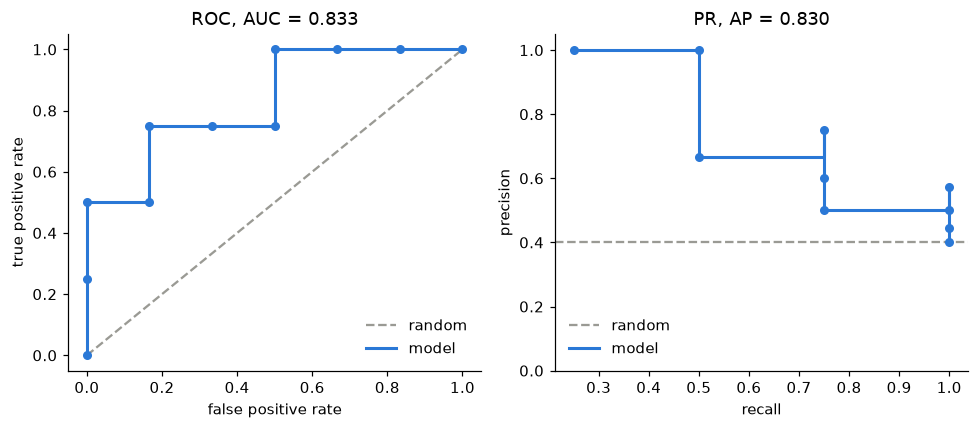

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.plot([0, 1], [0, 1], color=GRAY, lw=1.5, ls="--", label="random")
ax1.step(fpr, tpr, where="post", color=BLUE, lw=2, label="model")
ax1.scatter(fpr, tpr, color=BLUE, s=24, zorder=3)
ax1.set(xlabel="false positive rate", ylabel="true positive rate", title=f"ROC, AUC = {auc_trapezoid(fpr, tpr):.3f}")
ax1.legend(frameon=False, loc="lower right")

ax2.axhline(y.mean(), color=GRAY, lw=1.5, ls="--", label="random")
ax2.step(rec, prec, where="post", color=BLUE, lw=2, label="model")
ax2.scatter(rec, prec, color=BLUE, s=24, zorder=3)
ax2.set(xlabel="recall", ylabel="precision", ylim=(0, 1.05), title=f"PR, AP = {average_precision(scores, y):.3f}")
ax2.legend(frameon=False, loc="lower left")

plt.tight_layout()
plt.show()

## 8. The same functions on the real data

Now the stakes. Load every labeled provider and treat the rule-based flags from notebook 02
as if they were model scores. There is no model yet; this is the baseline the models will have
to beat.

Four candidate "scores," each just one column:

| score | what it is |
|---|---|
| `n_extreme` | how many features the provider is 3+ spreads out on |
| `max_abs_z` | the provider's single most extreme z-score |
| `z_srvcs_per_bene` | one feature alone: services per beneficiary, peer-adjusted |
| `z_em_high_share` | one feature alone: share of high-level office visits, peer-adjusted |

The pair-counting AUC above loops over every pair, which is fine for 24 pairs and hopeless for
68 x 1.3M. The version in `src/metrics.py` uses ranks instead, which is the same computation
done in one sort. That is the version used from here on.

**What this cell does:** pulls the labeled rows into pandas, fills missing z-scores with 0
(meaning "no evidence either way"), and imports the fast metric functions.

In [9]:
sys.path.insert(0, "C:/Users/palla/OneDrive/Documents/Coding Projects/Medicare Fraud ML/src")
import metrics as M

real = q("""
SELECT npi, label, n_extreme, max_abs_z, z_srvcs_per_bene, z_em_high_share
FROM provider_features
WHERE label IS NOT NULL
""")
for col in ["z_srvcs_per_bene", "z_em_high_share"]:
    real[col] = real[col].fillna(0.0)

y_real = real["label"].to_numpy()
print(f"{len(real):,} labeled providers, {y_real.sum()} positives, base rate = {y_real.mean():.6f}")

# sanity: the fast rank-based AUC must match the slow pair-counting one on the toy data
assert abs(M.auc_pairs(scores, y) - auc_pairs(scores, y)) < 1e-12
print("fast AUC matches slow AUC on the toy example")

1,296,658 labeled providers, 68 positives, base rate = 0.000052
fast AUC matches slow AUC on the toy example


**What this cell does:** scores all four candidates with ROC AUC, average precision, and
precision and recall at k = 100, 1,000, and 10,000. Also checks ROC AUC and AP against
scikit-learn on the real data, to be sure the hand-written versions hold up at scale.

**How to read it:**

- **ROC AUC of 0.5 is random.** Anything above it means the column ranks positives above
  negatives more often than not.
- **Average precision of 0.00005 is random**, because that is the base rate. Compare AP to
  that, not to 1.0.
- **Precision at 1,000 is the deployment number.** If investigators work 1,000 leads and the
  precision is 0.002, they find two real cases. Random would find 0.05.

In [10]:
CANDIDATES = ["n_extreme", "max_abs_z", "z_srvcs_per_bene", "z_em_high_share"]

rows = []
for c in CANDIDATES:
    s = real[c].to_numpy(dtype=float)
    r = M.summarize(s, y_real, ks=(100, 1000, 10000))
    r["sklearn_roc_auc"] = skm.roc_auc_score(y_real, s)
    r["sklearn_ap"] = skm.average_precision_score(y_real, s)
    rows.append(pd.Series(r, name=c))

results = pd.DataFrame(rows)
results["random_precision"] = y_real.mean()
results.T.round(5)

,n_extreme,max_abs_z,z_srvcs_per_bene,z_em_high_share
roc_auc,0.57557,0.60374,0.57832,0.54086
avg_precision,0.00008,0.00012,0.00008,0.00008
precision@100,0.00000,0.00000,0.00000,0.00000
recall@100,0.00000,0.00000,0.00000,0.00000
precision@1000,0.00000,0.00000,0.00000,0.00000
recall@1000,0.00000,0.00000,0.00000,0.00000
precision@10000,0.00010,0.00040,0.00000,0.00000
recall@10000,0.01471,0.05882,0.00000,0.00000
sklearn_roc_auc,0.57557,0.60374,0.57832,0.54086
sklearn_ap,0.00008,0.00012,0.00008,0.00008


## 9. What those numbers say

Every one of the four columns has a ROC AUC above 0.5, so each ranks the positives better than
chance. `max_abs_z` is the best at about 0.60. And every one of them has a **precision at
1,000 of exactly zero**. Not one of the 68 known positives lands in anyone's top 1,000.

Both facts are true at once, and that is the lesson of this notebook: **ROC AUC can look
respectable while the investigation queue contains no fraud at all**, because ROC never
divides by the number of things flagged. An AUC of 0.60 means "if you pick one positive and
one negative at random, the positive scores higher 60% of the time." It says nothing about
what is at the very top of the ranking, which is the only part investigators ever see.

Why the top is empty: the most extreme providers on any single feature are not fraud. They
are honest outliers, unusual specialties, data quirks, and the occasional huge practice.
The positives sit a modest half-spread from normal on several features at once, and
"modest on several" never wins a race against "enormous on one."

The useful comparison is precision at k against the base rate. That ratio is called **lift**.
At k = 10,000, `max_abs_z` catches 4 of the 68, a precision of 0.0004 against a base rate of
0.00005: a lift of about 8. The top 10,000 by that score are eight times richer in fraud than
a random 10,000. Real, and useless: 10,000 leads to find four cases.

This is the baseline. It is the number the models must beat, and it is low enough that beating
it will not be hard. The interesting question is how much.

**What this cell does:** draws the ROC and PR curves for the best single score on the real
data, with the random reference lines. On the PR panel the random line is at the base rate,
which is so close to zero it sits on the axis. That is what a 1-in-20,000 problem looks like.

One artifact to ignore: the PR curve shoots up to 1.0 at the far left. That is scikit-learn's
convention of starting every PR curve at (recall 0, precision 1), not a real data point. The
first actual point is wherever the top-scored provider lands, and here that is precision 0.

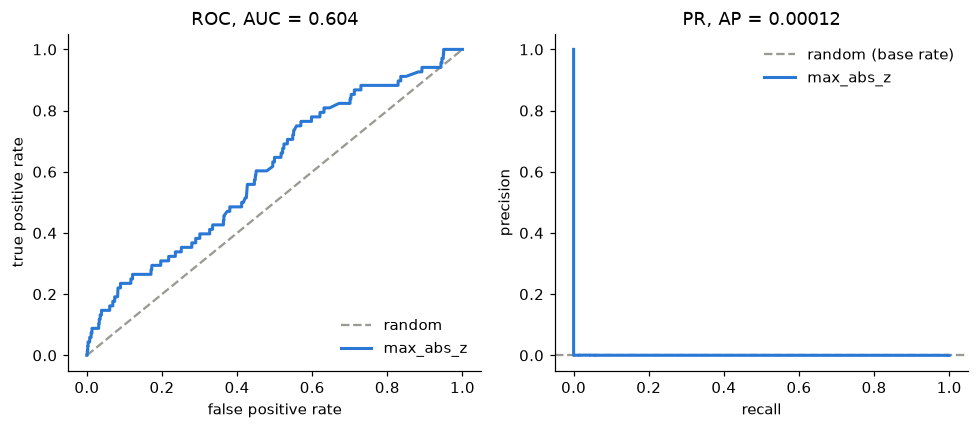

In [11]:
best = results["avg_precision"].idxmax()
s = real[best].to_numpy(dtype=float)

fpr_r, tpr_r, _ = skm.roc_curve(y_real, s)            # sklearn version, drops redundant points
prec_r, rec_r, _ = skm.precision_recall_curve(y_real, s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.plot([0, 1], [0, 1], color=GRAY, lw=1.5, ls="--", label="random")
ax1.plot(fpr_r, tpr_r, color=BLUE, lw=2, label=best)
ax1.set(xlabel="false positive rate", ylabel="true positive rate",
        title=f"ROC, AUC = {M.auc_pairs(s, y_real):.3f}")
ax1.legend(frameon=False, loc="lower right")

ax2.axhline(y_real.mean(), color=GRAY, lw=1.5, ls="--", label="random (base rate)")
ax2.plot(rec_r, prec_r, color=BLUE, lw=2, label=best)
ax2.set(xlabel="recall", ylabel="precision", title=f"PR, AP = {M.average_precision(s, y_real):.5f}")
ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

## 10. What to carry forward

Three things, and they are the answers to three interview questions.

**"How do you evaluate a fraud model?"** Ranking metrics, never accuracy. ROC AUC to compare
models and track drift, because it ignores the base rate. Precision at k to decide what ships,
because k is the investigators' capacity. Average precision when you need one number that
respects the imbalance.

**"What is AUC?"** The probability that a random positive outscores a random negative. Say it
that way and you have also said why it is threshold-free and why it ignores prevalence.

**"How do you pick the threshold?"** You usually do not. You pick k. If you must pick a
threshold, you write down the cost of a missed case and the cost of a wasted investigation
and minimize expected cost, which needs calibrated probabilities. That is the supervised
notebook's job.

The baseline is now on record: the best single column reaches the AUC and precision at 1,000
shown in section 8. The isolation forest in the next notebook has to beat it.

In [12]:
con.close()